# Question Group 1
Select 4 images with each label [0, 1, 6, 7]

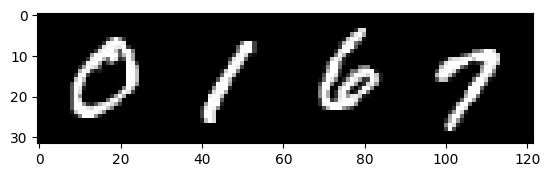

Labels: [0, 1, 6, 7]


In [114]:
import torch
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Define a transform to convert the images to tensors
transform = transforms.Compose([
  transforms.ToTensor()
  # transforms.Normalize((0.5,), (0.5,))  # (original - 0.5)/0.5 = normalized
])

# Download the MNIST dataset
train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
# train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
# For validation dataset
valid_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)
# valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False)

# Filter for the desired labels (0, 1, 6, 7)
desired_labels = [0, 1, 6, 7]
# randomly pick 4 images
def filter_dataset(dataset, labels):
    filtered_data = []
    found = set()
    for i, (image, label) in enumerate(dataset):
        if label in labels and label not in found:
            filtered_data.append((image, label))
            found.add(label)
        if len(found) == len(labels):
            break
    return filtered_data

train_data = filter_dataset(train_dataset, desired_labels)
valid_data = filter_dataset(valid_dataset, desired_labels)

# Extract images and labels
def stack_data(data):
  images = torch.stack([img for img, _ in data])  # shape: [4, 1, 28, 28]
  labels = [label for _, label in data]
  return images, labels

# show the image
train_data_imgs, train_data_labels = stack_data(filter_dataset(train_dataset, desired_labels))
val_data_imgs, val_data_labels = stack_data(filter_dataset(valid_dataset, desired_labels))

def imshow(img):
  # img = img / 2 + 0.5     # unnormalize
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.show()

# Use make_grid to put images in one row
grid = utils.make_grid(train_data_imgs, nrow=4, padding=2, normalize=False)
imshow(grid)

# Print labels
print("Labels:", train_data_labels)

dataloader

In [115]:
from torch.utils.data import DataLoader, TensorDataset

# Step 1: 攤平成向量 & 轉成 tensor
def prepare_tensor_dataset(data):
    images = [img.view(-1) for img, _ in data]  # 攤平成 784 向量
    labels = [label for _, label in data]
    x_tensor = torch.stack(images)              # shape: [4, 784]
    y_tensor = torch.tensor(labels)             # shape: [4]
    return TensorDataset(x_tensor, y_tensor)

# Step 2: 包成 dataloader，設定 batch_size = 1
train_dataset_specific = prepare_tensor_dataset(train_data)
train_loader = DataLoader(train_dataset_specific, batch_size=1, shuffle=True)

valid_dataset_specific = prepare_tensor_dataset(valid_data)
valid_loader = DataLoader(valid_dataset_specific, batch_size=1, shuffle=False)

Define autoencoder

In [116]:
import torch
import torch.nn as nn

# Model structure
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 4),
            nn.Tanh(),
            nn.Linear(4, 1),
            nn.Tanh()
        )
    def forward(self, inputs):
        codes = self.encoder(inputs)
        return codes

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(1, 4),
            nn.Tanh(),
            nn.Linear(4, 32),
            nn.Tanh(),
            nn.Linear(32, 64),
            nn.Tanh(),
            nn.Linear(64, 128),
            nn.Tanh(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )
    def forward(self, inputs):
        outputs = self.decoder(inputs)
        return outputs

class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()
        # Encoder
        self.encoder = Encoder()
        # Decoder
        self.decoder = Decoder()

    def forward(self, inputs):
        codes = self.encoder(inputs)
        decoded = self.decoder(codes)
        return codes, decoded

Define VAE  
ref: https://medium.com/@rekalantar/variational-auto-encoder-vae-pytorch-tutorial-dce2d2fe0f5f

In [117]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, enc_out_dim=200, latent_dim=2):
        super(VAE, self).__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, enc_out_dim),
            nn.LeakyReLU(0.2)
            )

        # latent mean and variance
        self.mean_layer = nn.Linear(enc_out_dim, latent_dim)
        self.logvar_layer = nn.Linear(enc_out_dim, latent_dim)

        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, enc_out_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(enc_out_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim),
            nn.Tanh()
            )

    def encode(self, x):
        x = self.encoder(x)
        mean, logvar = self.mean_layer(x), self.logvar_layer(x)
        return mean, logvar

    # 使得 VAE 能夠用反向傳播訓練 Encoder 裡的 mean 和 logvar
    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var)
        z = mean + var*epsilon
        return z

    def decode(self, x):
        return self.decoder(x)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterization(mean, logvar)
        x_hat = self.decode(z)
        return z, x_hat, mean, logvar

Determine device

In [118]:
# Device will determine whether to run the training on GPU or CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


Autoencoder training

In [119]:
from torch.optim import Adam

def training(lr, epochs, model, x_train, x_val):
  """
    parameters:
      lr: learning rate
      epochs: number of epochs
      model: model
      x_train: training data
      x_val: validation data
  """
  model = model.to(device)
  criterion = nn.MSELoss()
  optimizer = Adam(model.parameters(), lr=lr)
  epochs = epochs

  loss_values = []
  valid_loss_values = []
  Min_loss = 1e9


  for epoch in range(1, epochs+1):

      train_loss = 0.0
      valid_loss = 0.0

      for (i, (x_train, _)) in enumerate(train_loader):
        model.train()
        x_train = x_train.to(device)

        optimizer.zero_grad()
        codes, decoded = model(x_train)
        # 看原來跟起始輸入的差
        loss = criterion(decoded, x_train)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

      train_loss /= len(train_loader) # average
      loss_values.append(train_loss)
      print(f"Epoch {epoch}: Loss = {train_loss:.6f}")

      # test valid
      for (i, (x_val, _)) in enumerate(valid_loader.dataset):
        model.eval()
        with torch.no_grad():
            x_val = x_val.to(device)  # 你需先定義 x_val
            _, val_decoded = model(x_val)
            val_loss = criterion(val_decoded, x_val)
            valid_loss += val_loss.item()

      valid_loss /= len(valid_loader.dataset) # average
      valid_loss_values.append(valid_loss)
      print(f"         Valid Loss = {valid_loss:.6f}")

      if valid_loss < Min_loss:
        Min_loss = valid_loss
        torch.save(model.state_dict(), 'AE.pth')
        print("Model saved!")

  return loss_values, valid_loss_values

In [120]:
model = AutoEncoder()
loss_values, valid_loss_values = training(0.0005, 10, model, train_loader, valid_loader)

Epoch 1: Loss = 0.230020
         Valid Loss = 0.226210
Model saved!
Epoch 2: Loss = 0.222164
         Valid Loss = 0.218127
Model saved!
Epoch 3: Loss = 0.212691
         Valid Loss = 0.207574
Model saved!
Epoch 4: Loss = 0.200177
         Valid Loss = 0.193822
Model saved!
Epoch 5: Loss = 0.184079
         Valid Loss = 0.176568
Model saved!
Epoch 6: Loss = 0.164230
         Valid Loss = 0.156362
Model saved!
Epoch 7: Loss = 0.141434
         Valid Loss = 0.134829
Model saved!
Epoch 8: Loss = 0.117882
         Valid Loss = 0.114623
Model saved!
Epoch 9: Loss = 0.096640
         Valid Loss = 0.098213
Model saved!
Epoch 10: Loss = 0.079806
         Valid Loss = 0.086818
Model saved!


Variational Autoencoder training

In [121]:
def loss_function(x, x_hat, mean, log_var):
    # KL-divergence + Generation Loss
    mse_loss = nn.MSELoss()
    reproduction_loss = mse_loss(x_hat, x)
    KLD = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + KLD

In [122]:
def train(model, optimizer, epochs, train_loader, valid_loader, device):
    model.train()

    loss_values = []
    valid_loss_values = []
    Min_loss = 1e9

    for epoch in range(epochs):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            # flattern
            x = x.view(1, 28*28).to(device)

            optimizer.zero_grad()

            z, x_hat, mean, log_var = model(x)
            loss = loss_function(x, x_hat, mean, log_var)

            overall_loss += loss.item()

            loss.backward()
            optimizer.step()

        overall_loss /= len(train_loader.dataset)
        loss_values.append(overall_loss)
        print("\tEpoch", epoch + 1, "\tAverage Loss: ", overall_loss)

        # valid test
        for i, (x_val, _) in enumerate(valid_loader):
          valid_loss = 0.0
          with torch.no_grad():
              x_val = x_val.view(1, 28*28).to(device)
              z, x_hat, mean, log_var = model(x_val)
              loss = loss_function(x_val, x_hat, mean, log_var)

              valid_loss += loss.item()

        valid_loss /= len(valid_loader.dataset)
        valid_loss_values.append(valid_loss)
        print(f"\t        \t Valid Loss = {valid_loss:.6f}")

        if valid_loss < Min_loss:
          Min_loss = valid_loss
          torch.save(model.state_dict(), 'VAE.pth')
          print("\tModel saved!")

    return loss_values, valid_loss_values

model = VAE(input_dim=784, hidden_dim=400, enc_out_dim=200, latent_dim=1).to(device)
optimizer = Adam(model.parameters(), lr=0.001)
VAE_loss_values, VAE_valid_loss_values = train(model, optimizer, epochs=10, train_loader=train_loader, valid_loader=valid_loader, device=device)

	Epoch 1 	Average Loss:  0.11096674762666225
	        	 Valid Loss = 0.024010
	Model saved!
	Epoch 2 	Average Loss:  0.10178118944168091
	        	 Valid Loss = 0.020727
	Model saved!
	Epoch 3 	Average Loss:  0.06252404674887657
	        	 Valid Loss = 0.022002
	Epoch 4 	Average Loss:  0.053340911865234375
	        	 Valid Loss = 0.023627
	Epoch 5 	Average Loss:  0.05659162998199463
	        	 Valid Loss = 0.023722
	Epoch 6 	Average Loss:  0.053261357359588146
	        	 Valid Loss = 0.022734
	Epoch 7 	Average Loss:  0.05289819836616516
	        	 Valid Loss = 0.021842
	Epoch 8 	Average Loss:  0.0514144841581583
	        	 Valid Loss = 0.021628
	Epoch 9 	Average Loss:  0.050850589759647846
	        	 Valid Loss = 0.021565
	Epoch 10 	Average Loss:  0.050490766763687134
	        	 Valid Loss = 0.021765


Visualize to Loss Variation

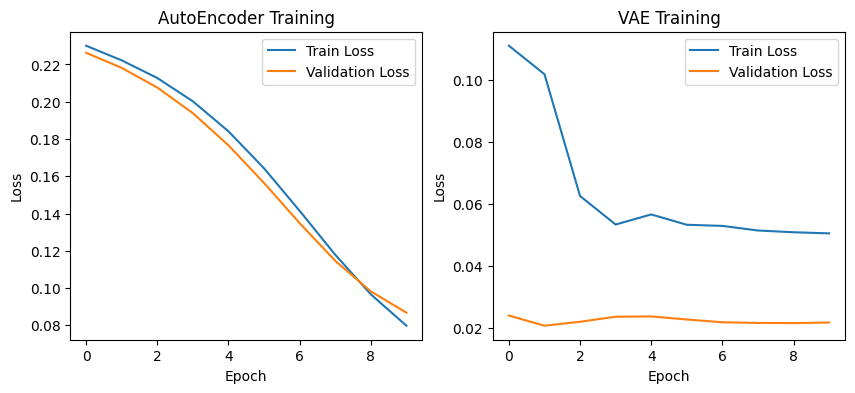

In [123]:
# loss variation
def draw_loss(loss_values, valid_loss_values, VAE_loss_values, VAE_valid_loss_values):
  plt.figure(figsize=(10, 4))  # 調整圖片大小
  for i in range(2):
    plt.subplot(1, 2, i+1)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    if i == 0:
      plt.title('AutoEncoder Training')
      plt.plot(loss_values, label='Train Loss')
      plt.plot(valid_loss_values, label='Validation Loss')
    else:
      plt.title('VAE Training')
      plt.plot(VAE_loss_values, label='Train Loss')
      plt.plot(VAE_valid_loss_values, label='Validation Loss')
    plt.legend()
  plt.show()

draw_loss(loss_values, valid_loss_values, VAE_loss_values, VAE_valid_loss_values)

show latent code

In [124]:
def question_1(model, train_loader, autoencoder=True):
  model = model.to(device)
  output = []
  labels = []
  for (i, (x_train, y_train)) in enumerate(train_loader):
    with torch.no_grad():
        x_train = x_train.to(device)
        if autoencoder:
            codes, decoded = model(x_train)
        else:
            codes, decoded, _, _ = model(x_train)

    # 顯示 latent code
    print(f"Label: {y_train.item()}, Latent code: {codes.item():.4f}")
    output.append(decoded.view(28, 28))
    labels.append(y_train.item())

  # 顯示重建圖片
  for i in range(4):
      plt.subplot(1, 4, i+1)
      plt.imshow(output[i].view(28, 28), cmap="gray")
      plt.title(f"Label: {labels[i]}")
      plt.axis("off")
  plt.show()

AutoEncoder Testing...

Label: 0, Latent code: 0.3263
Label: 1, Latent code: 0.3483
Label: 6, Latent code: 0.3202
Label: 7, Latent code: 0.3327


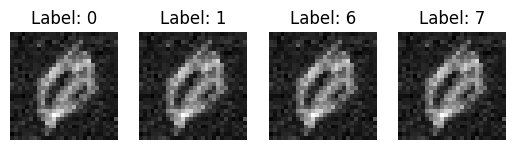

In [125]:
print("AutoEncoder Testing...\n")
model = AutoEncoder()
model.load_state_dict(torch.load('AE.pth'))
question_1(model, train_loader)

Variational AutoEncoder Testing...

Label: 7, Latent code: -0.0222
Label: 1, Latent code: 0.0319
Label: 6, Latent code: 0.3558
Label: 0, Latent code: -0.1921


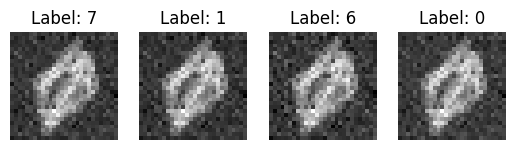

In [126]:
print("Variational AutoEncoder Testing...\n")
model = VAE(input_dim=784, hidden_dim=400, enc_out_dim=200, latent_dim=1)
model.load_state_dict(torch.load('VAE.pth'))
question_1(model, train_loader, False)

Compared diffent output with latent code and Visulized

In [127]:
def question_2(model):
  with torch.no_grad():
      latent_values = torch.linspace(-3, 3, steps=10).unsqueeze(1)  # shape: (10, 1)
      generated = model.decoder(latent_values)

  for i in range(10):
      plt.subplot(1, 10, i+1)
      plt.imshow(generated[i].view(28, 28), cmap="gray")
      plt.title(f"{latent_values[i].item():.2f}")
      plt.axis("off")
  plt.show()
  return generated.view(-1, 28, 28).cpu().numpy(), latent_values # for futher comparsion (10, 28, 28)

AutoEncoder Testing...



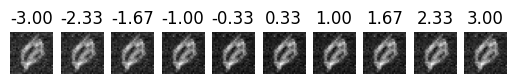

In [128]:
print("AutoEncoder Testing...\n")
model = AutoEncoder()
model.load_state_dict(torch.load('AE.pth'))
AE_img, AE_latent = question_2(model)

Variational AutoEncoder Testing...



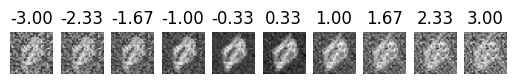

In [129]:
print("Variational AutoEncoder Testing...\n")
model = VAE(input_dim=784, hidden_dim=400, enc_out_dim=200, latent_dim=1)
model.load_state_dict(torch.load('VAE.pth'))
VAE_img, VAE_latent = question_2(model)

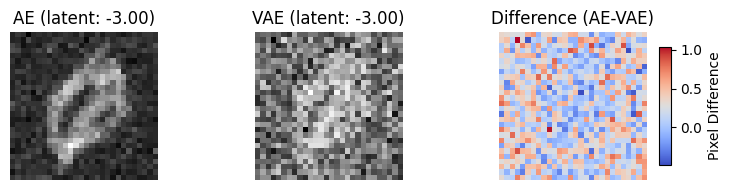

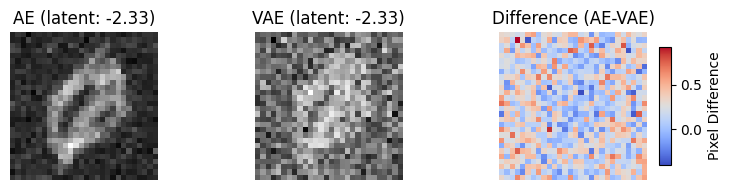

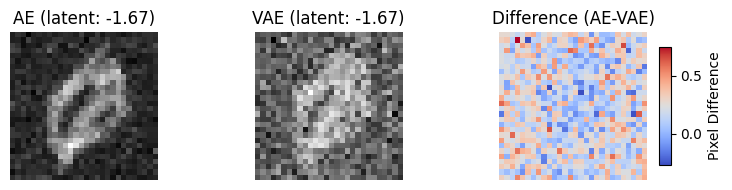

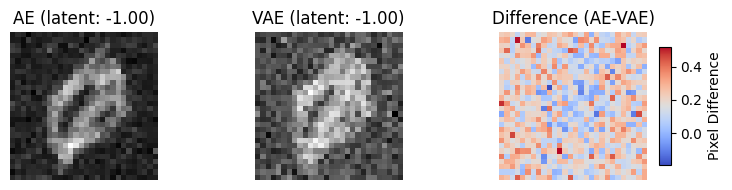

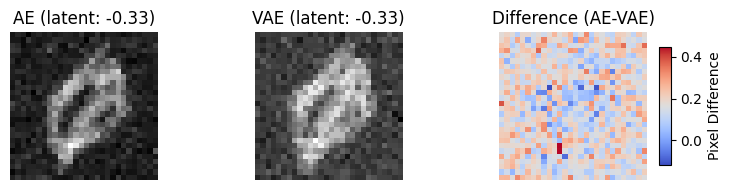

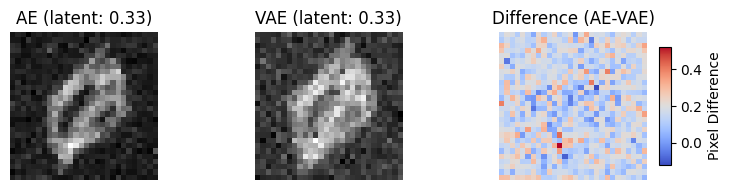

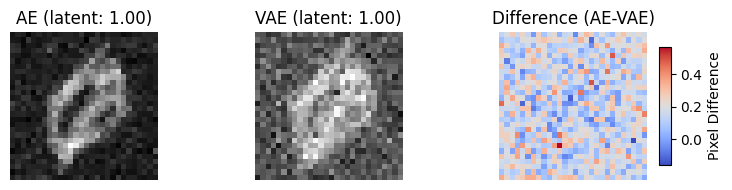

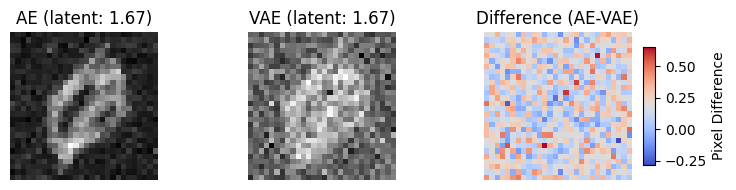

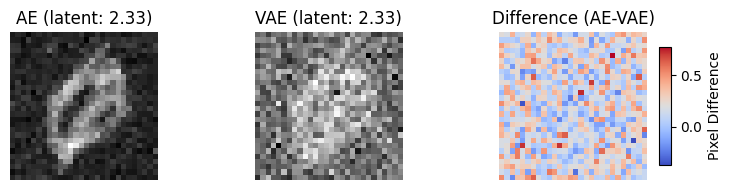

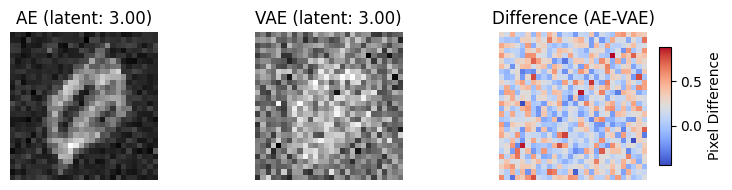

In [130]:
def visualize_difference_colored_grid(ae_generated, vae_generated, latent_values):
    """Visualizes AE, VAE and difference image in separate figures per row, each with their own colorbar."""
    num_images = len(ae_generated)

    for i in range(num_images):
        ae_img_np = ae_generated[i]
        vae_img_np = vae_generated[i]
        latent_value = latent_values[i]

        diff = ae_img_np - vae_img_np

        fig, axes = plt.subplots(1, 3, figsize=(8, 2))  # 每組圖片一行，三張子圖

        # AE image
        axes[0].imshow(ae_img_np, cmap='gray')
        axes[0].set_title(f"AE (latent: {latent_value.item():.2f})")
        axes[0].axis("off")

        # VAE image
        axes[1].imshow(vae_img_np, cmap='gray')
        axes[1].set_title(f"VAE (latent: {latent_value.item():.2f})")
        axes[1].axis("off")

        # Difference image with colorbar
        im = axes[2].imshow(diff, cmap='coolwarm')
        axes[2].set_title("Difference (AE-VAE)")
        axes[2].axis("off")
        cbar = fig.colorbar(im, ax=axes[2], shrink=0.8, aspect=10, pad=0.05)
        cbar.set_label('Pixel Difference')

        plt.tight_layout()
        plt.show()

visualize_difference_colored_grid(AE_img, VAE_img, AE_latent)

# Question Group 2
train with entire MNIST with VAE model  
latent space dimension = 2

In [131]:
BATCH_SIZE = 32
train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
# For validation dataset
valid_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

for (i, (x_train, y_train)) in enumerate(train_loader):
  print(x_train.shape)
  print(y_train.shape)
  break

for (i, (x_train, y_train)) in enumerate(valid_loader):
  print(x_train.shape)
  print(y_train.shape)
  break

torch.Size([32, 1, 28, 28])
torch.Size([32])
torch.Size([32, 1, 28, 28])
torch.Size([32])


In [132]:
def loss_function_v2(x, x_hat, mean, log_var, mode):
    # KL-divergence + Generation Loss
    mse_loss = nn.MSELoss()
    reproduction_loss = mse_loss(x_hat, x)
    KLD = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    if mode == "recon":
        return reproduction_loss
    elif mode == "kl":
        return KLD
    else:
        return reproduction_loss + KLD

In [153]:
def train_VAE_v2(model, optimizer, epochs, train_loader, valid_loader, loss_mode, device):
    model.train()

    loss_values = []
    valid_loss_values = []
    Min_loss = 1e9

    for epoch in range(epochs):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            # flattern
            x = x.view(-1, 28*28).to(device)

            optimizer.zero_grad()

            z, x_hat, mean, log_var = model(x)

            loss = loss_function_v2(x, x_hat, mean, log_var, loss_mode)

            overall_loss += loss.item()

            loss.backward()
            optimizer.step()

        overall_loss /= len(train_loader.dataset)
        loss_values.append(overall_loss)
        print("\tEpoch", epoch + 1, "\tAverage Loss: ", overall_loss)

        # valid test
        valid_loss = 0.0
        for i, (x_val, _) in enumerate(valid_loader):
          with torch.no_grad():
              x_val = x_val.view(-1, 28*28).to(device)
              z, x_hat, mean, log_var = model(x_val)
              loss = loss_function_v2(x_val, x_hat, mean, log_var, loss_mode)

              valid_loss += loss.item()

        valid_loss /= len(valid_loader.dataset)
        valid_loss_values.append(valid_loss)
        print(f"\t        \t Valid Loss = {valid_loss:.6f}")

        if valid_loss < Min_loss:
          Min_loss = valid_loss
          torch.save(model.state_dict(), 'VAE_v2.pth')
          print("\tModel saved!")

    return loss_values, valid_loss_values

In [134]:
# loss variation
def draw_VAE_loss(VAE_loss_values, VAE_valid_loss_values, mode):
  plt.figure(figsize=(5, 4))  # 調整圖片大小
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title(f'VAE Training, mode = {mode}')
  plt.plot(VAE_loss_values, label='Train Loss')
  plt.plot(VAE_valid_loss_values, label='Validation Loss')
  plt.legend()
  plt.show()

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_latent_scatter(mean, std, labels, title="Latent Space (μ)", mode = 'mean'):
    # 轉成 pandas dataframe
    df = pd.DataFrame({
        "μ₁": mean[:, 0],
        "μ₂": mean[:, 1],
        "σ₁": std[:, 0],
        "σ₂": std[:, 1],
        "label": labels
    })

    if mode == 'mean':
      x = "μ₁"
      y = "μ₂"
    else:
      x = "σ₁"
      y = "σ₂"

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=x, y=y, hue="label", palette="tab10", s=15, alpha=0.8)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.legend(title="Digit")
    plt.grid(True)
    plt.show()

In [136]:
def distribution(model, train_loader, valid_loader):
  mu_list, std_list, label_list = [], [], []

  for x, y in train_loader:
      x = x.view(-1, 784).to(device)
      z, x_hat, mean, log_var = model(x)
      # trace back to Normal standard
      std = torch.exp(0.5 * log_var)

      mu_list.append(mean.detach().cpu())
      std_list.append(std.detach().cpu())
      label_list.append(y)

  for x, y in valid_loader:
      x = x.view(-1, 784).to(device)
      z, x_hat, mean, log_var = model(x)
      std = torch.exp(0.5 * log_var)

      mu_list.append(mean.detach().cpu())
      std_list.append(std.detach().cpu())
      label_list.append(y)

  mu_all = torch.cat(mu_list)
  std_all = torch.cat(std_list)
  labels_all = torch.cat(label_list)

  plot_latent_scatter(mu_all, std_all, labels_all, "Mean (μ) Distribution of Latent Space", mode = 'mean')
  plot_latent_scatter(std_all, std_all, labels_all, "Standard Deviation (σ) Distribution", mode = 'std')


In [137]:
# when pass latent vector to decoder, it will generate image based on what VAE learned.
def generate_digit(x, y):
    z_sample = torch.tensor([[x, y]], dtype=torch.float).to(device) # pass random latent vector
    x_decoded = model.decode(z_sample)
    digit = x_decoded.detach().cpu().reshape(28, 28) # reshape vector to 2d array
    plt.imshow(digit, cmap='gray')
    plt.axis('off')
    plt.show()

Since defining each necessary function, later we deal with problem set 2:  
* training the model with different loss and show its mean and variation distribution (2-dimension).
* describe the affect with uniform distribution

1. MSE_LOSS

In [154]:
# MSE_LOSS
model = VAE(input_dim=784, hidden_dim=400, enc_out_dim=200, latent_dim=2).to(device)
optimizer = Adam(model.parameters(), lr=0.001)
VAE_loss_values, VAE_valid_loss_values = train_VAE_v2(model, optimizer, epochs=5, train_loader=train_loader, valid_loader=valid_loader, loss_mode = "recon", device=device)

	Epoch 1 	Average Loss:  0.0014909066846594213
	        	 Valid Loss = 0.001387
	Model saved!
	Epoch 2 	Average Loss:  0.0013576290886849166
	        	 Valid Loss = 0.001336
	Model saved!
	Epoch 3 	Average Loss:  0.0013166520163416862
	        	 Valid Loss = 0.001293
	Model saved!
	Epoch 4 	Average Loss:  0.0012950680982942383
	        	 Valid Loss = 0.001282
	Model saved!
	Epoch 5 	Average Loss:  0.0012798291180903714
	        	 Valid Loss = 0.001273
	Model saved!


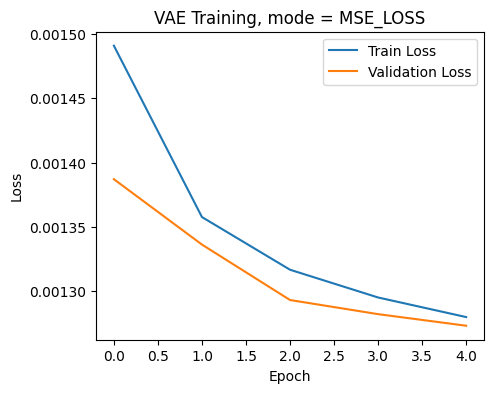

In [155]:
draw_VAE_loss(VAE_loss_values, VAE_valid_loss_values, "MSE_LOSS")

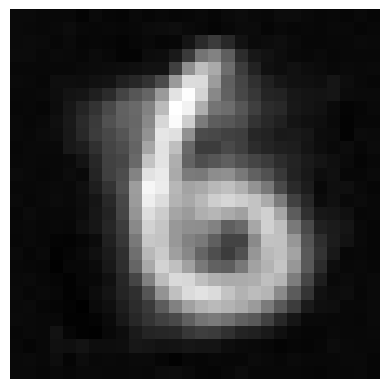

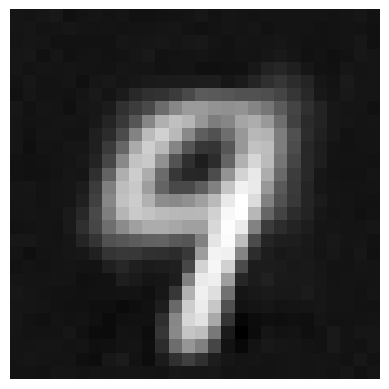

(None, None)

In [156]:
generate_digit(0.0, 1.0), generate_digit(1.0, 0.0)

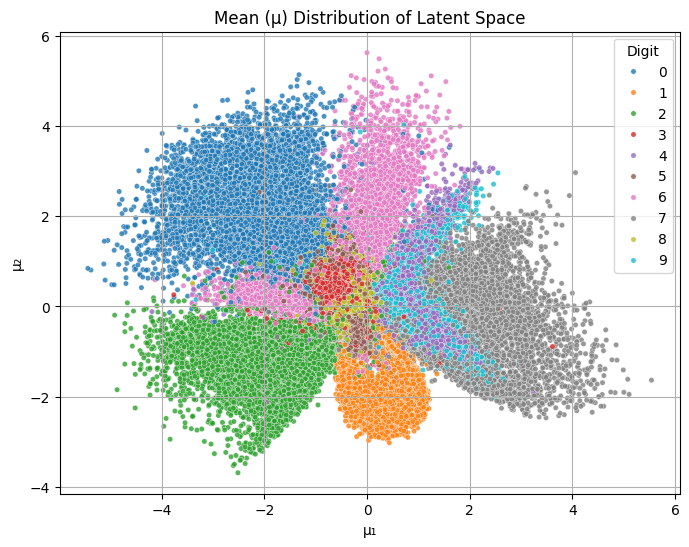

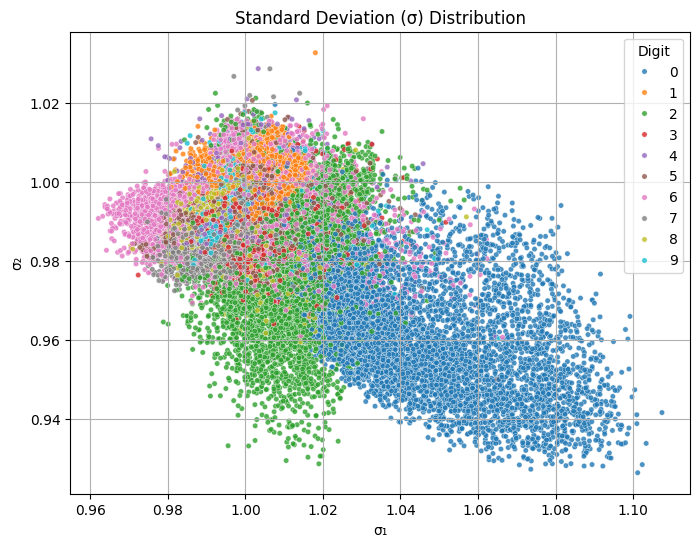

In [157]:
distribution(model, train_loader, valid_loader)

2. KL LOSS

In [158]:
# KL_LOSS
model = VAE(input_dim=784, hidden_dim=400, enc_out_dim=200, latent_dim=2).to(device)
optimizer = Adam(model.parameters(), lr=0.001)
VAE_loss_values, VAE_valid_loss_values = train_VAE_v2(model, optimizer, epochs=5, train_loader=train_loader, valid_loader=valid_loader, loss_mode = "kl", device=device)

	Epoch 1 	Average Loss:  5.661488672097524e-05
	        	 Valid Loss = 0.000001
	Model saved!
	Epoch 2 	Average Loss:  6.695707639058431e-07
	        	 Valid Loss = 0.000000
	Model saved!
	Epoch 3 	Average Loss:  4.81972595055898e-07
	        	 Valid Loss = 0.000001
	Epoch 4 	Average Loss:  2.0820299784342447e-07
	        	 Valid Loss = 0.000000
	Model saved!
	Epoch 5 	Average Loss:  2.0533303419748943e-07
	        	 Valid Loss = 0.000000


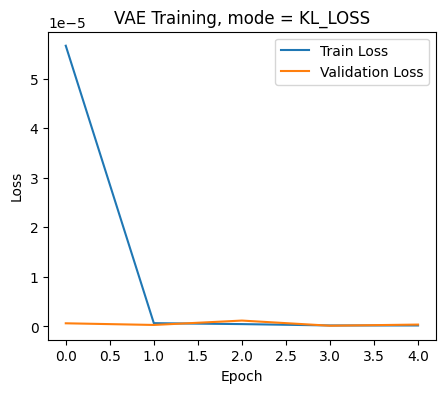

In [159]:
draw_VAE_loss(VAE_loss_values, VAE_valid_loss_values, "KL_LOSS")

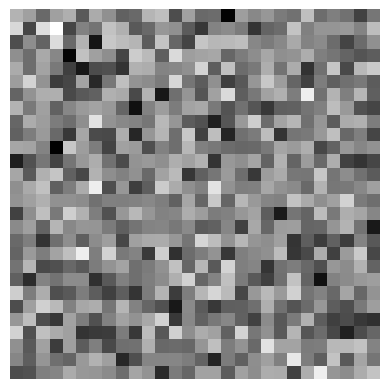

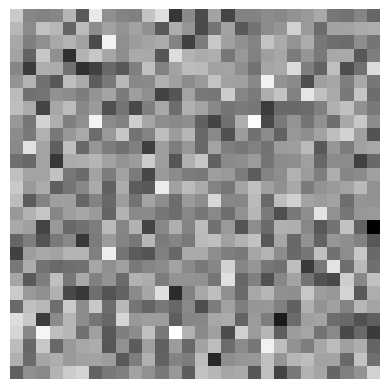

(None, None)

In [160]:
generate_digit(0.0, 1.0), generate_digit(1.0, 0.0)

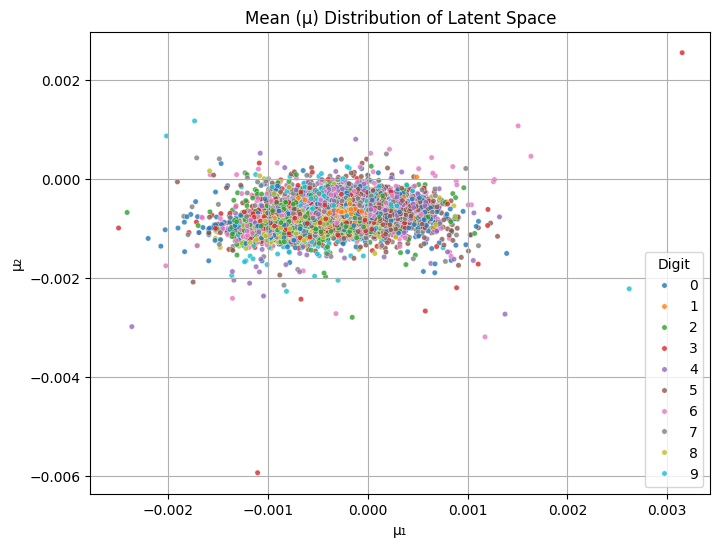

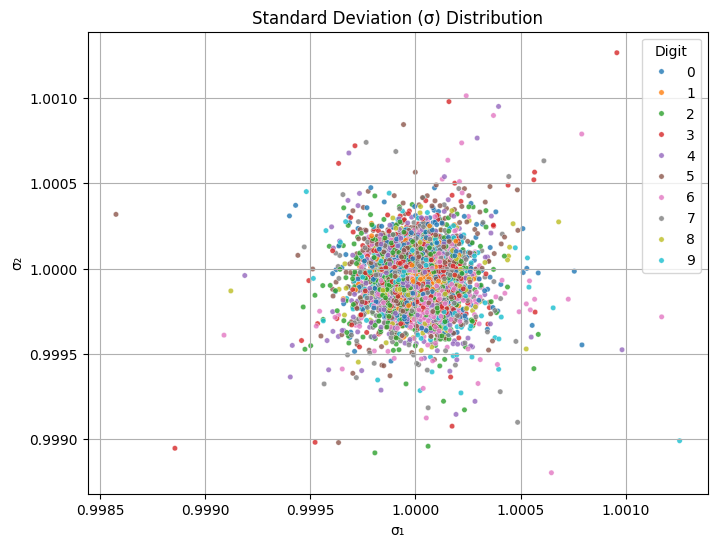

In [161]:
distribution(model, train_loader, valid_loader)

3. MSE + KL divergence

In [162]:
# Both_LOSS
model = VAE(input_dim=784, hidden_dim=400, enc_out_dim=200, latent_dim=2).to(device)
optimizer = Adam(model.parameters(), lr=0.001)
VAE_loss_values, VAE_valid_loss_values = train_VAE_v2(model, optimizer, epochs=5, train_loader=train_loader, valid_loader=valid_loader, loss_mode = "both", device=device)

	Epoch 1 	Average Loss:  0.0020371482146903873
	        	 Valid Loss = 0.001896
	Model saved!
	Epoch 2 	Average Loss:  0.0018229257493590316
	        	 Valid Loss = 0.001760
	Model saved!
	Epoch 3 	Average Loss:  0.0016661591919139027
	        	 Valid Loss = 0.001619
	Model saved!
	Epoch 4 	Average Loss:  0.0015998061439643303
	        	 Valid Loss = 0.001598
	Model saved!
	Epoch 5 	Average Loss:  0.001565121739730239
	        	 Valid Loss = 0.001544
	Model saved!


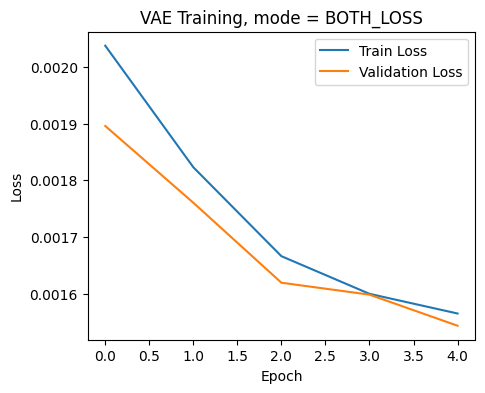

In [163]:
draw_VAE_loss(VAE_loss_values, VAE_valid_loss_values, "BOTH_LOSS")

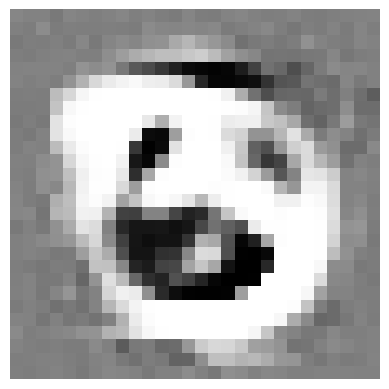

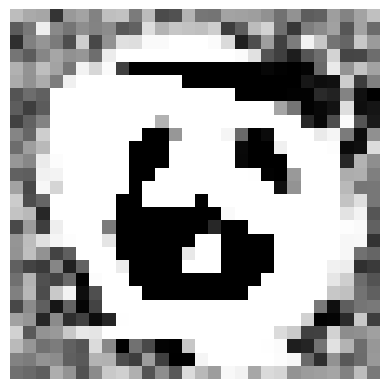

(None, None)

In [164]:
generate_digit(0.1, 0.0), generate_digit(1.0, 0.0)

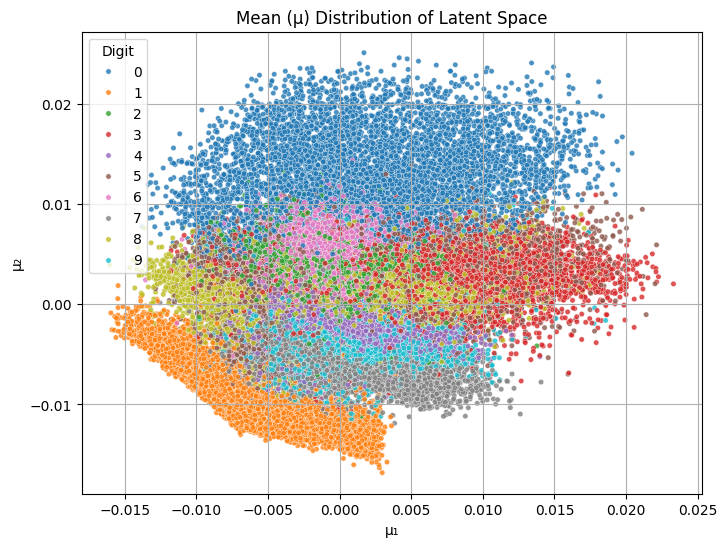

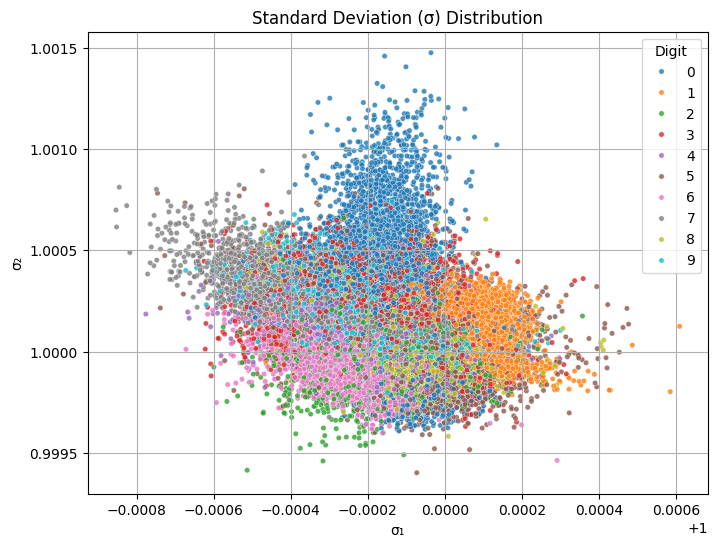

In [165]:
distribution(model, train_loader, valid_loader)

ii.   
在 Variation AutoEncoder (VAE) 當中加入的 KL-divergence 使其 latent space 近似高斯分布，讓模型不只能重建圖片，還能學到潛在的語意特徵。  
如果改用 uniform distribution，將可能使模型認為這 latent space 內的向量所出現的機率是均等的，進而讓生成圖片變得更隨機、不穩定，導致圖片生成結果難以還原原始圖片。